In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [17]:
data = loadmat('cluster_dataset.mat')

In [18]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

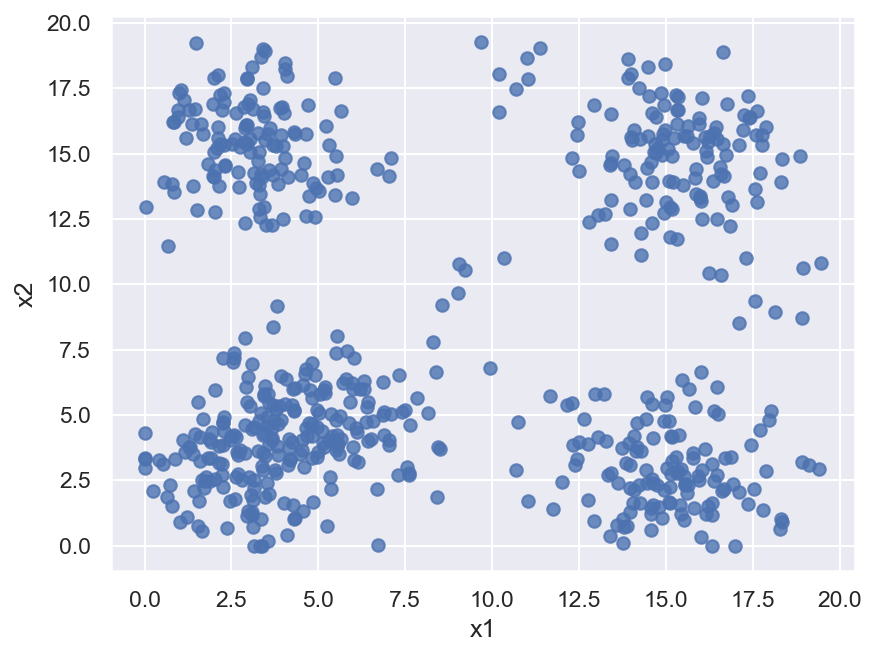

In [19]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [20]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [21]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    #获取样本数量
    sample_number=X.shape[0]

    #没有用random.randint()，而是用了numpy的random.choice()
    random_result=np.random.choice(sample_number,k,replace=False)

    #随机的结果作为中心
    centers=X[random_result]
    
    return centers

In [22]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    #欧氏距离计算
    distance=np.sqrt(np.sum((v1-v2)**2))
   
    return distance

In [23]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
    k = centers.shape[0]
    n_samples = X.shape[0]
    
    # 将两个要计算距离的矩阵向量化
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    
    #计算每个样本到每个中心的欧氏距离
    distances = np.sqrt(np.sum(diff ** 2, axis=2))
    
    #计算每个样本所属的最近簇的索引
    labels = np.argmin(distances, axis=1)
    
    #构建返回值要求的字典格式
    assignment = {i: [] for i in range(k)}
    
    #将样本根据 label 分组
    for i in range(k):
        #用np.where()返回满足条件的索引数组
        member_indices = np.where(labels == i)[0]
        if len(member_indices) > 0:
            # X[member_indices] 取出的是 ndarray，放入 list 中
            assignment[i] = [X[member_indices]] 
            
    # 重新构建字典方式以兼容后续的plot_clustering()和center_update()函数
    assignment = {i: [] for i in range(k)}
    #将每个样本分配到相应的簇
    for idx, cluster_id in enumerate(labels):
        assignment[cluster_id].append(X[idx])
        
    return assignment


In [24]:
#代价函数：计算所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
    total_distace=0
    sample_number=0
    #两层循环，计算每个簇中的样本到对应中心的总距离total_distance
    for number,samples in assignment.items():
        center=centers[number]
        for sample in samples:
            total_distace+=distance(sample,center)
            sample_number+=1
        #用平均距离代表cost
        cost=total_distace/sample_number
    
    return cost

In [25]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    k=centers.shape[0]
    new_centers=np.zeros_like(centers)
    stop=1#初始先设置为停机，通过一轮迭代后触发不停机的条件
    for cluster_id in range(k):
        #对于每一个簇中的样本，如果簇中样本不为空，则计算新的中心，否则中心不变
        samples=assignment[cluster_id]
        if len(samples)>0:
            #转化为ndarray
            cluster_array=np.array(samples)
            #取平均更新中心
            new_center=np.mean(cluster_array,axis=0)
        else:
            new_center=centers[cluster_id]
        #将计算出的新中心保存在new_centers中
        new_centers[cluster_id]=new_center
        #通过np.allclose()函数判断是否收敛
        if not np.allclose(new_center,centers[cluster_id]):
            #若收敛则不停机
            stop=0
    return new_centers, stop

In [26]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [27]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
    #初始化中心
    centers=init_centers(X,k)
    for epoch in range(max_epoch):
        #对于每一次迭代，先分配样本到最近的簇，然后计算代价，最后更新直至收敛或达到最大迭代次数
        assignment=cluster_assignment(X,centers)
        cost=cost_function(assignment,centers)
        new_centers,stop=center_update(assignment,centers)
        if plot:
            plot_clustering(assignment,centers,epoch)
        if stop:
            print("收敛于第{}次迭代".format(epoch))
            break
        centers=new_centers
    return assignment, cost

In [28]:
max_epoch = 200 

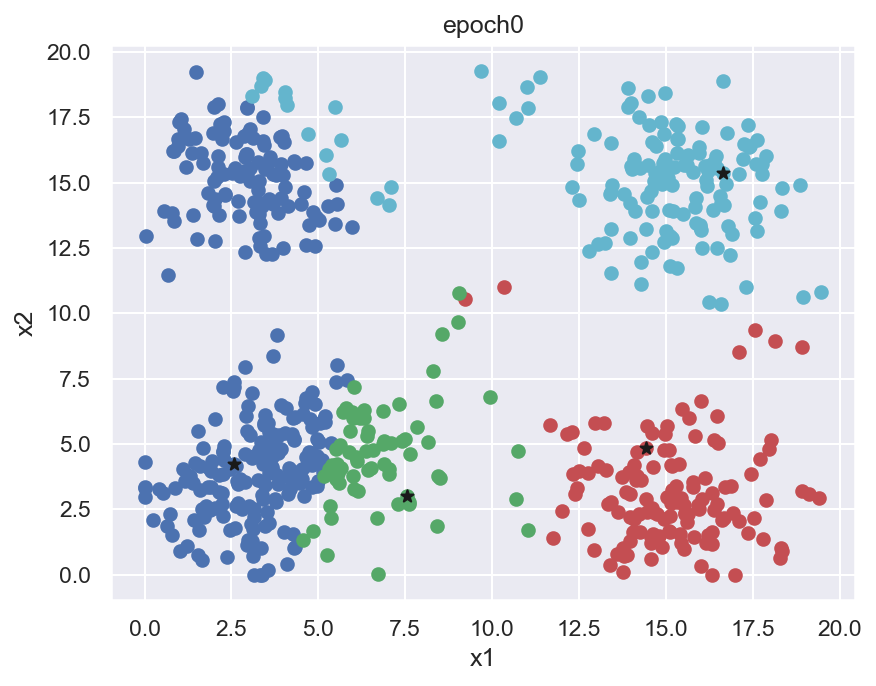

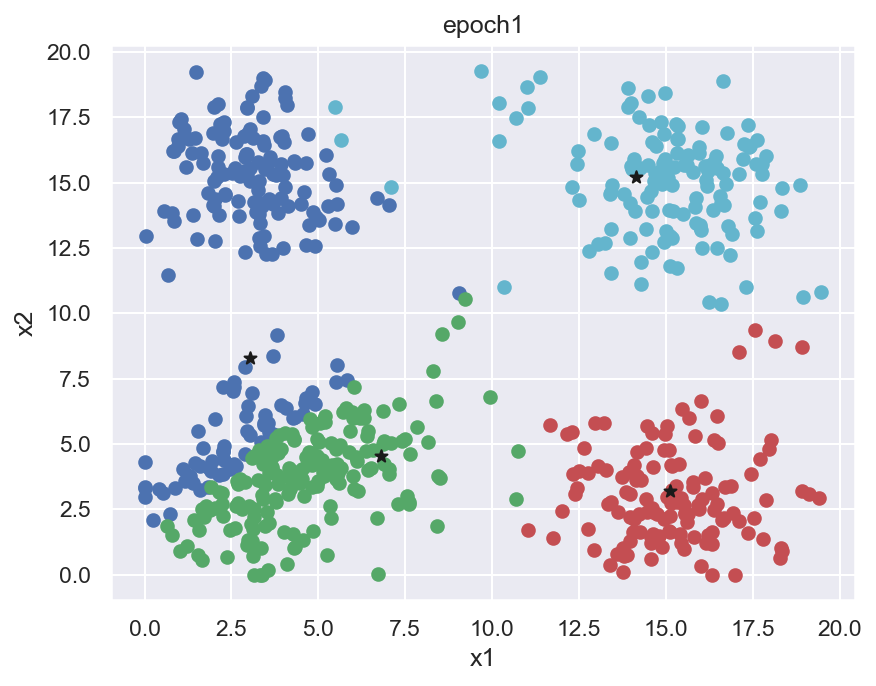

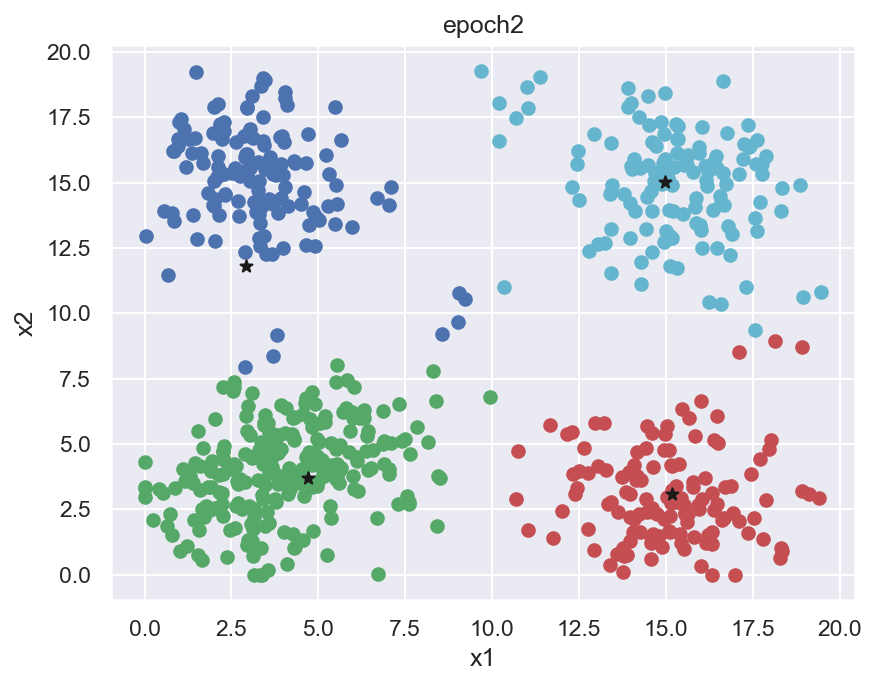

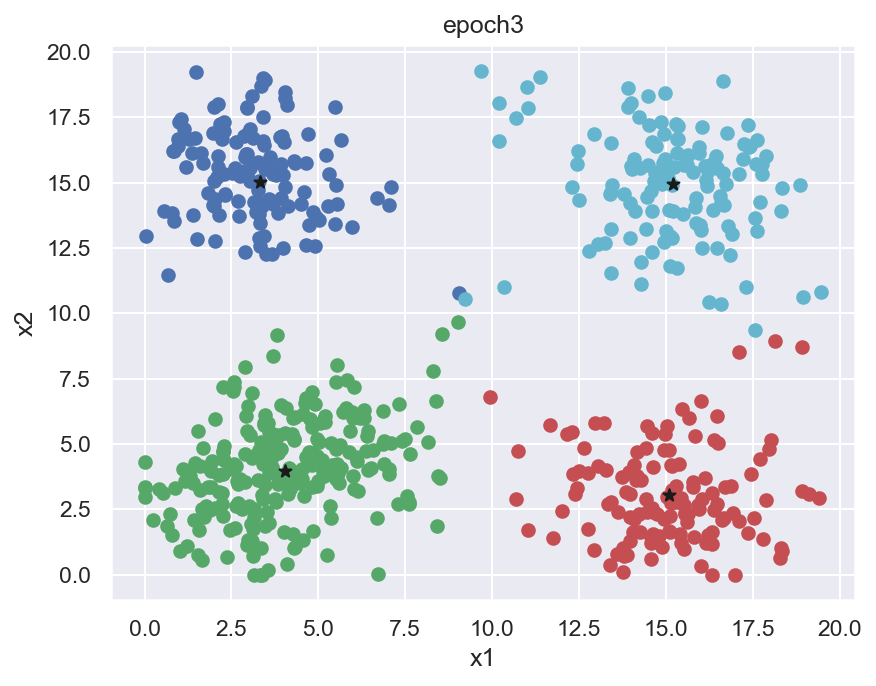

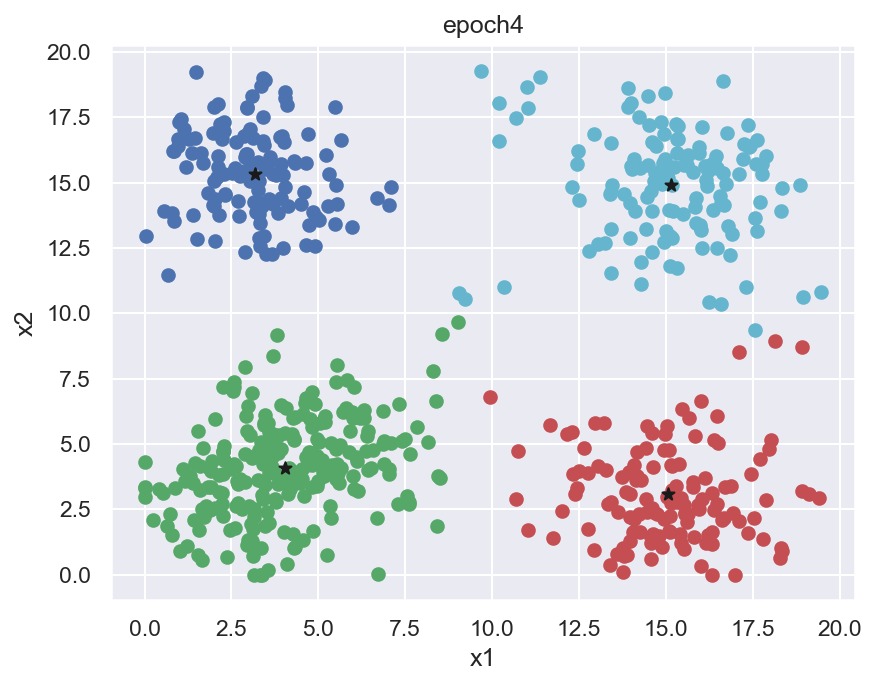

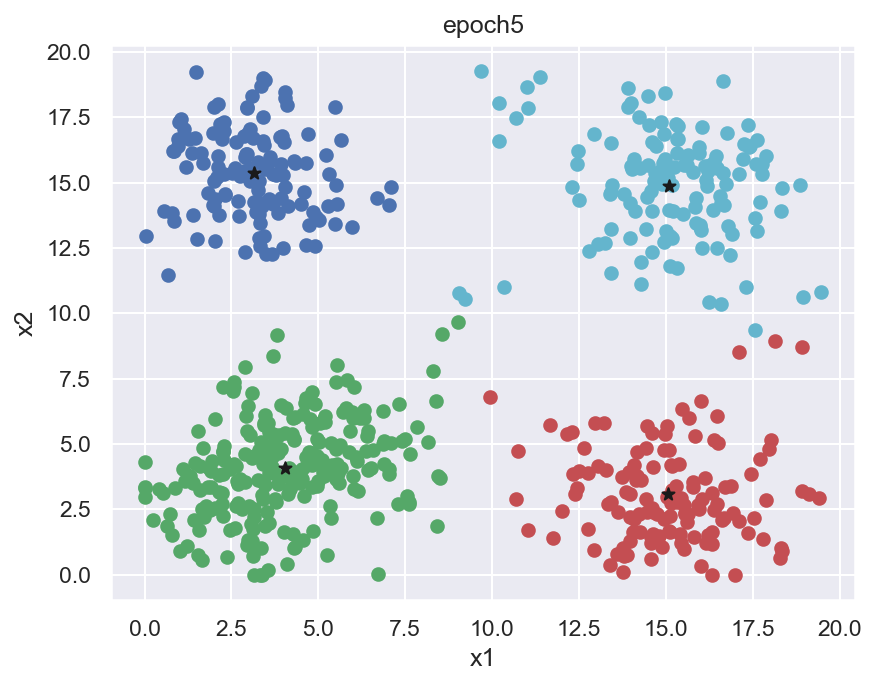

收敛于第5次迭代


In [29]:
assignment, cost= kmeans(X, k, max_epoch)

<Figure size 960x720 with 0 Axes>

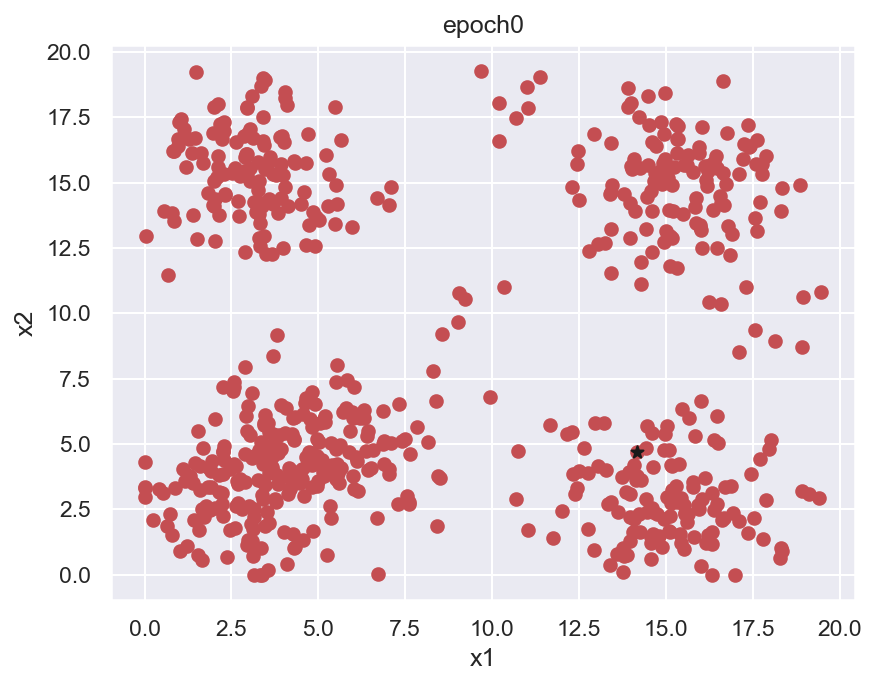

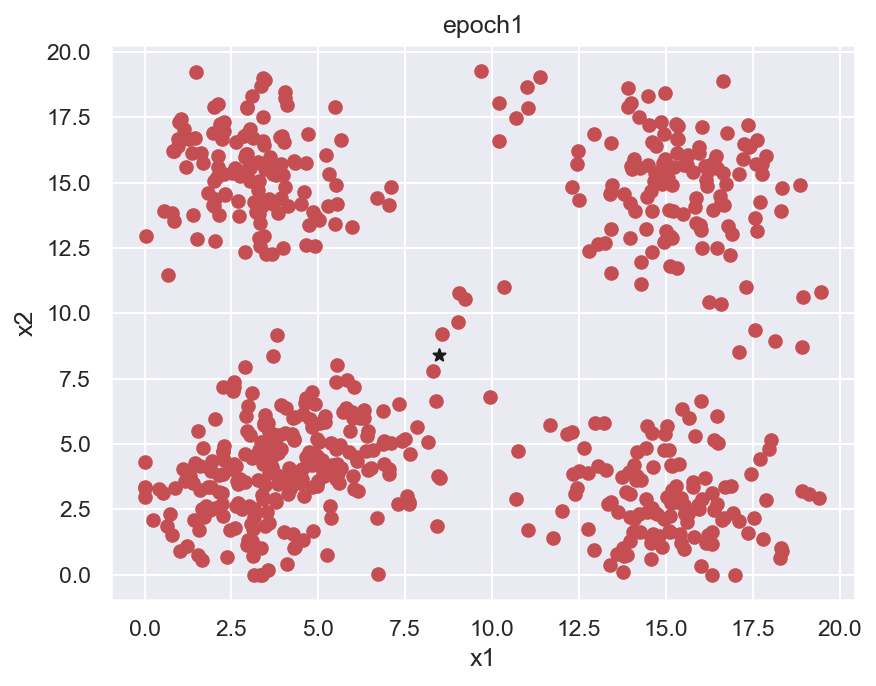

收敛于第1次迭代


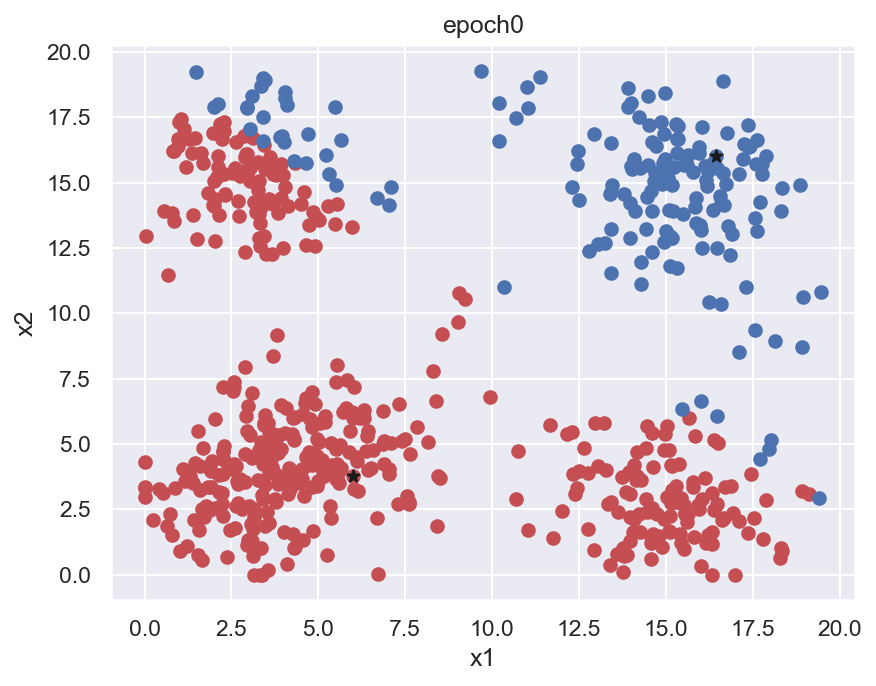

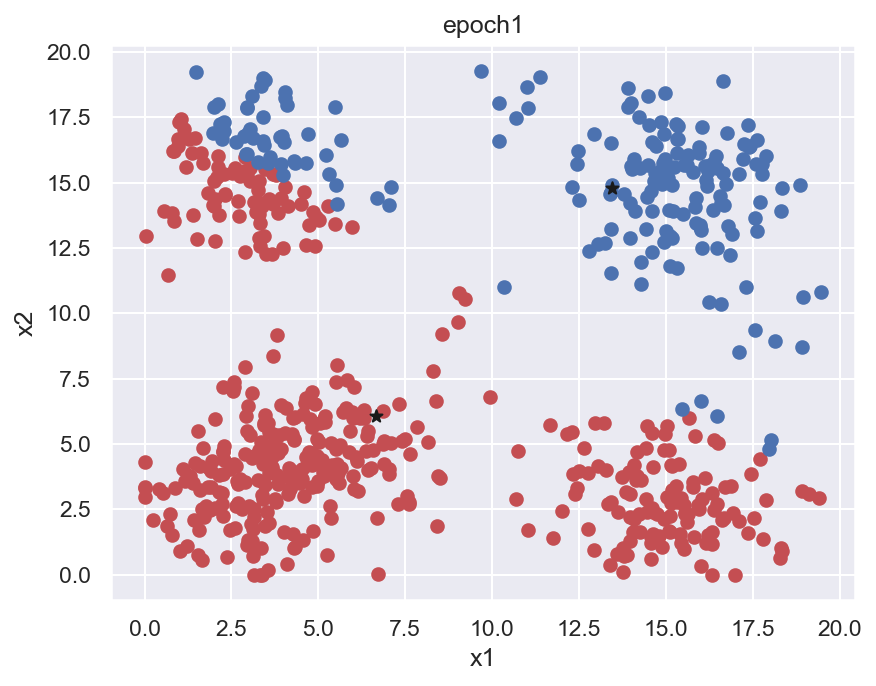

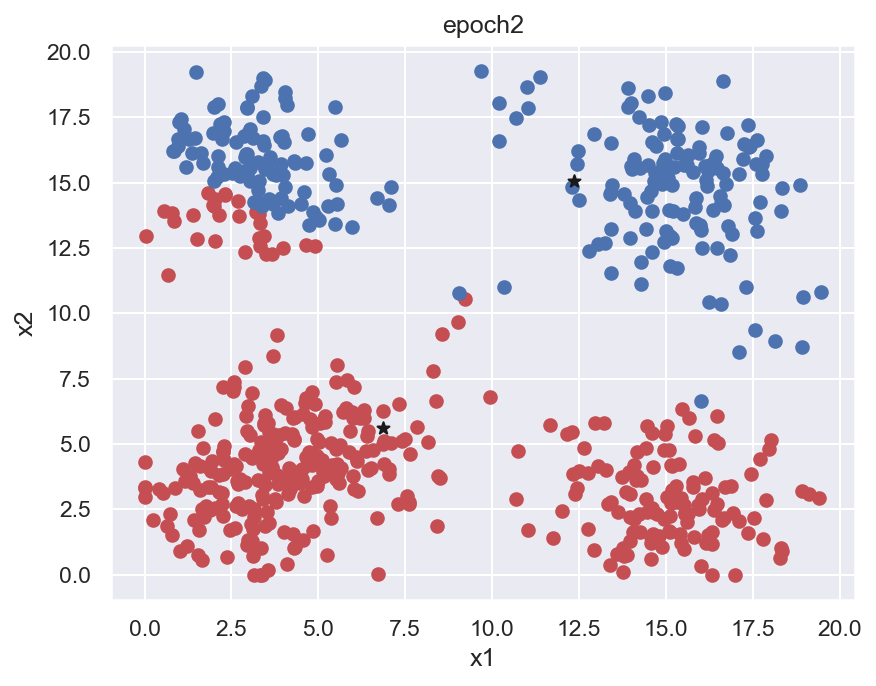

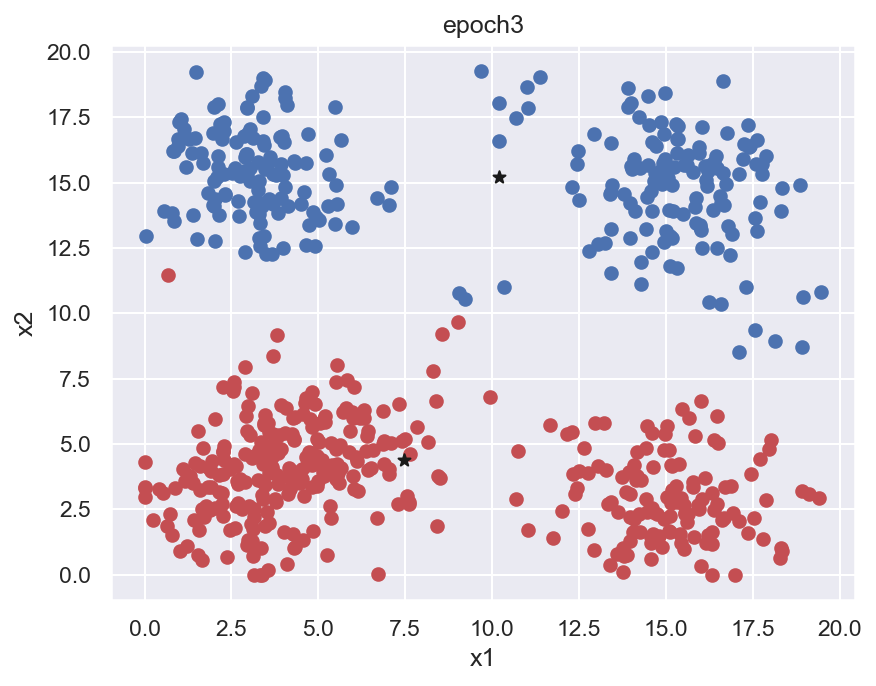

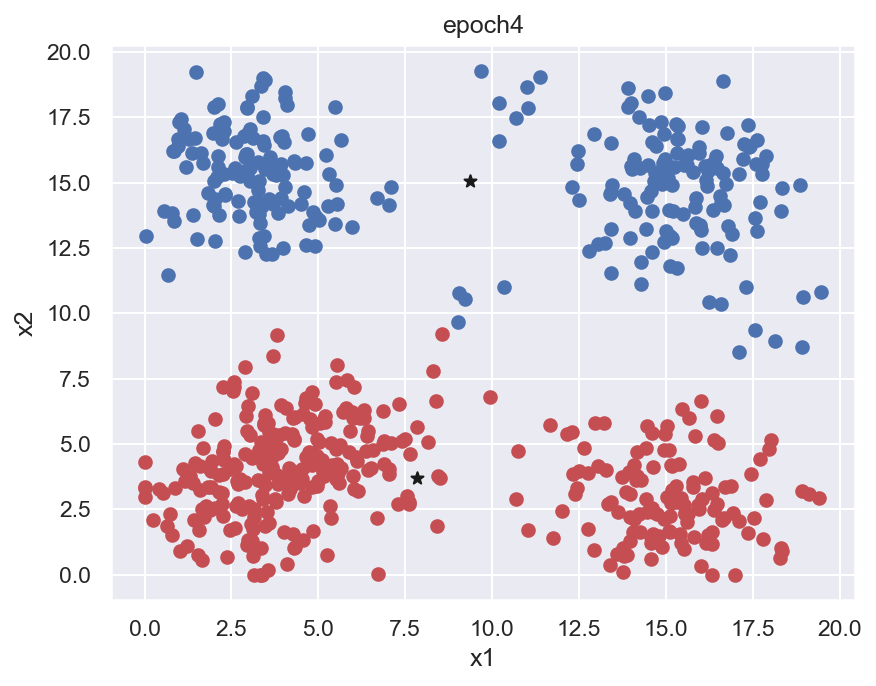

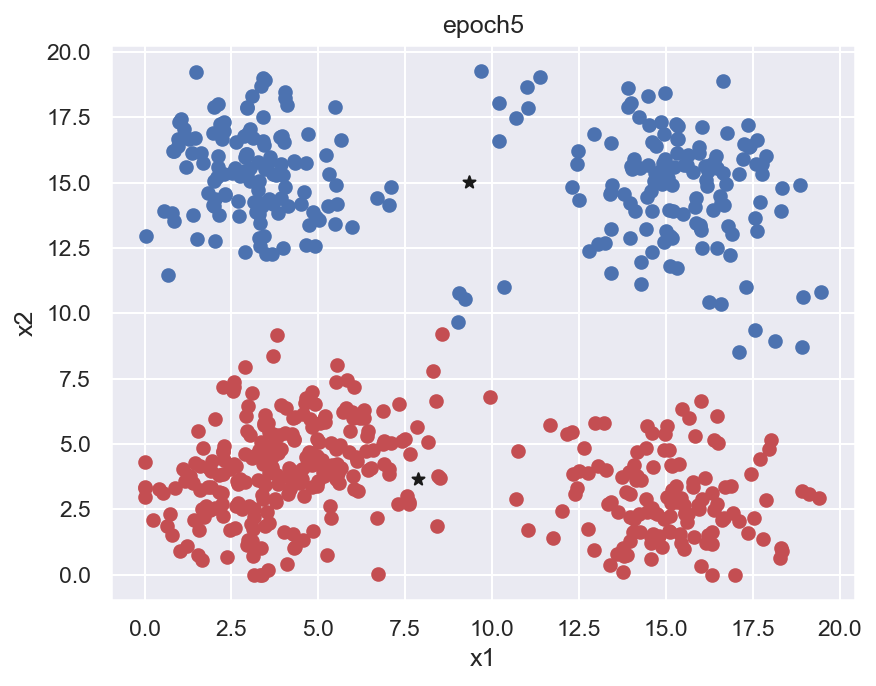

收敛于第5次迭代


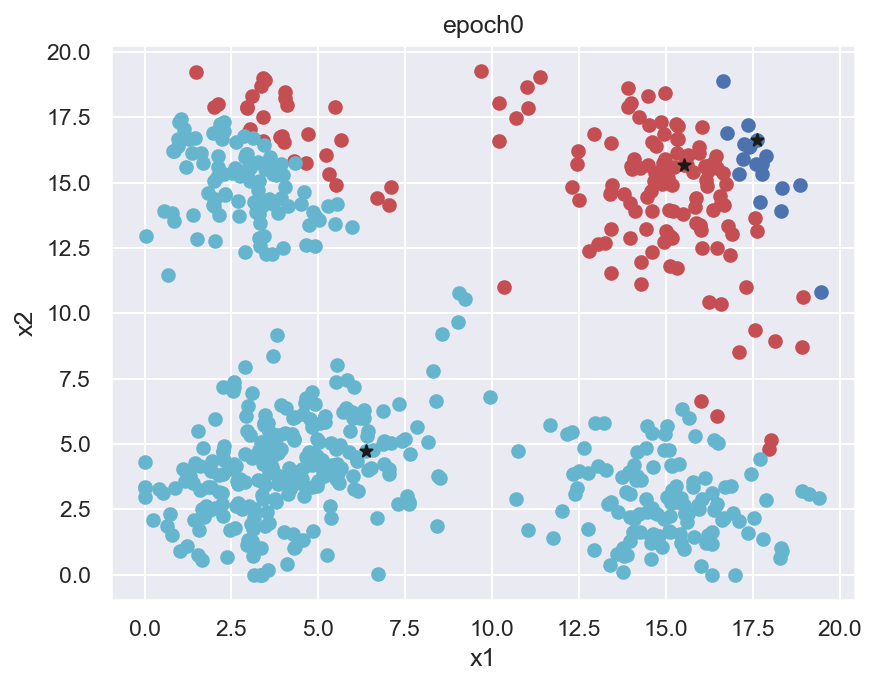

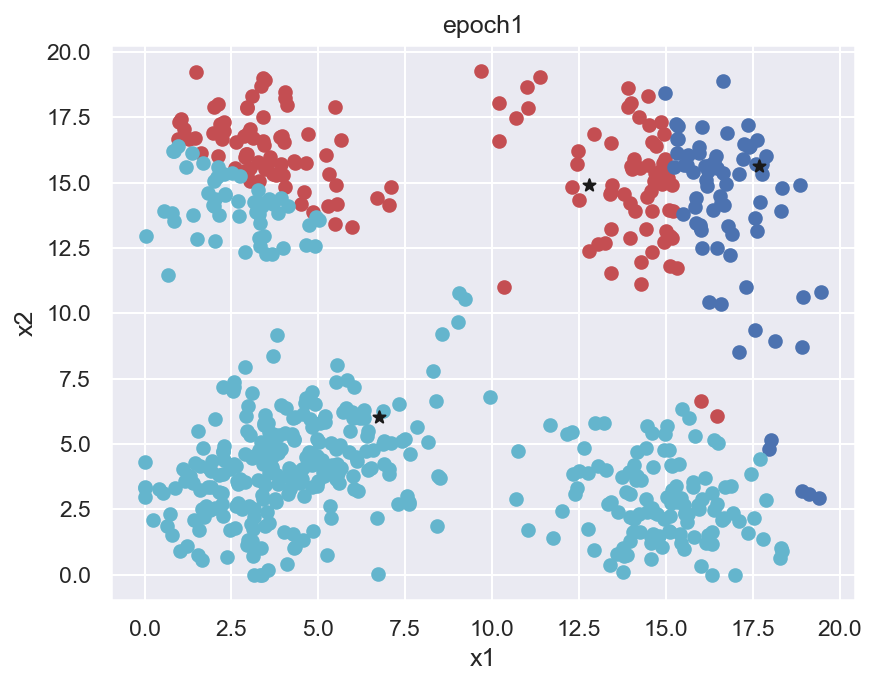

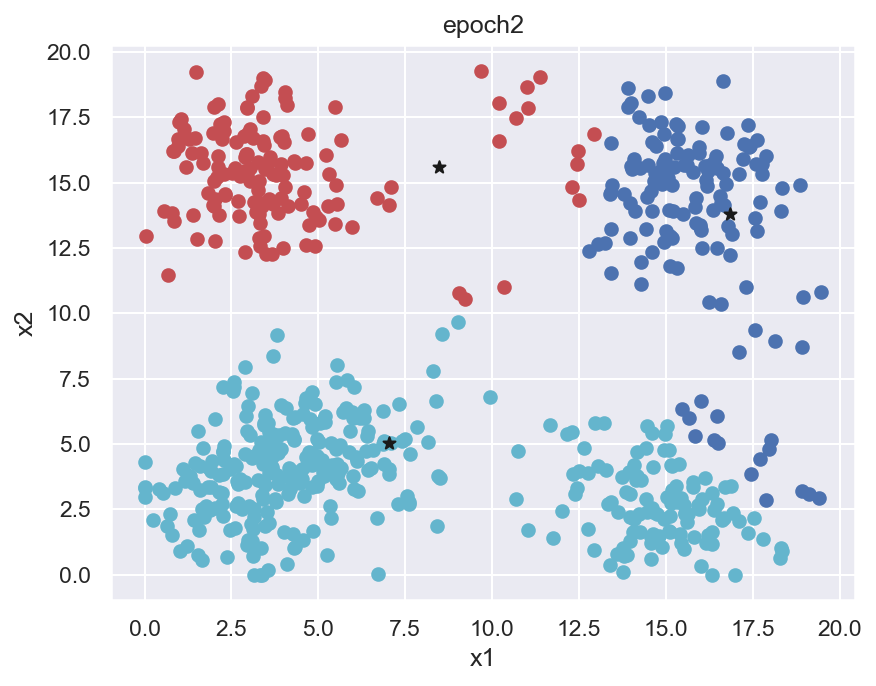

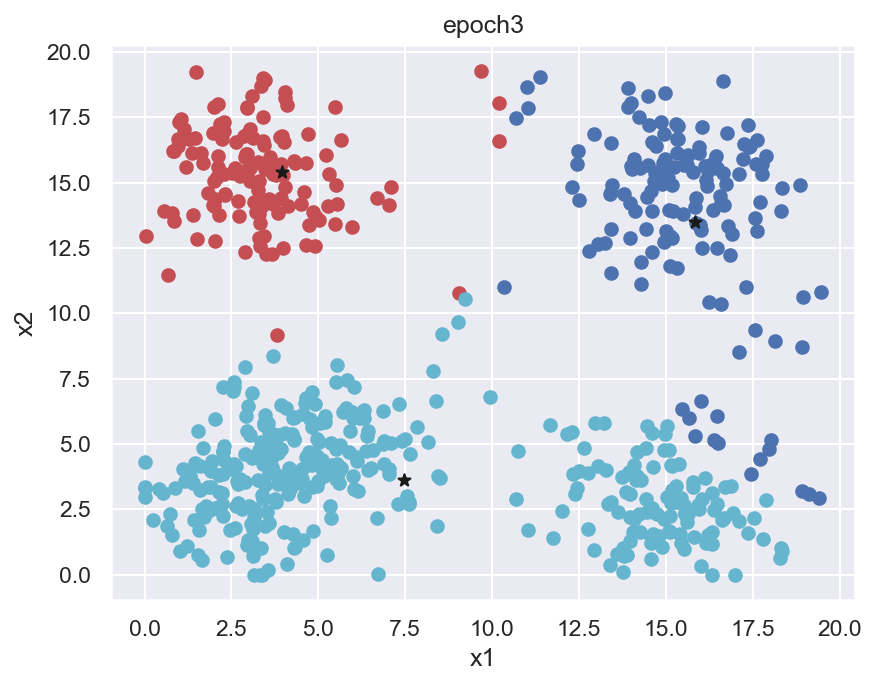

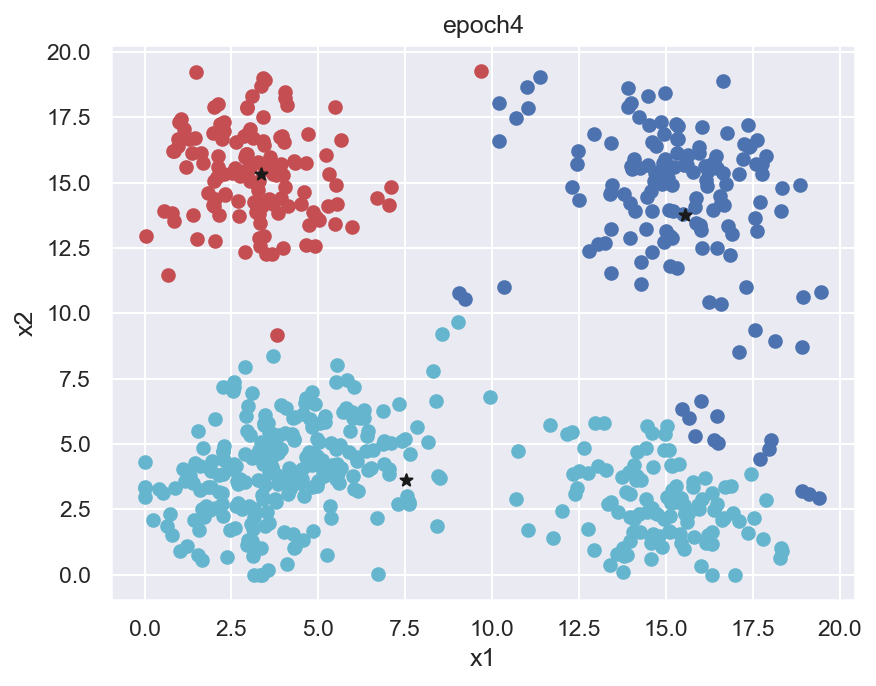

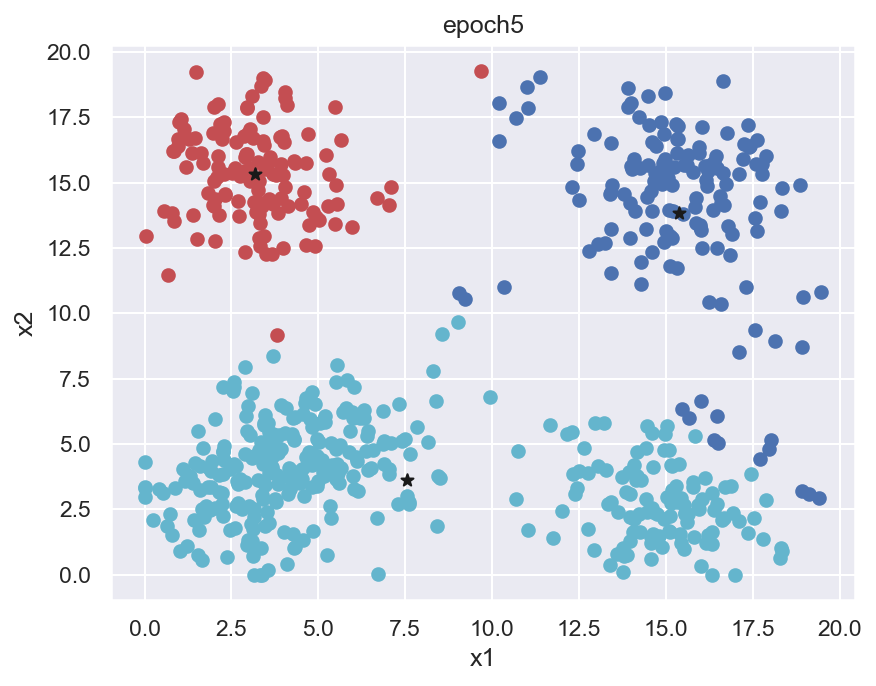

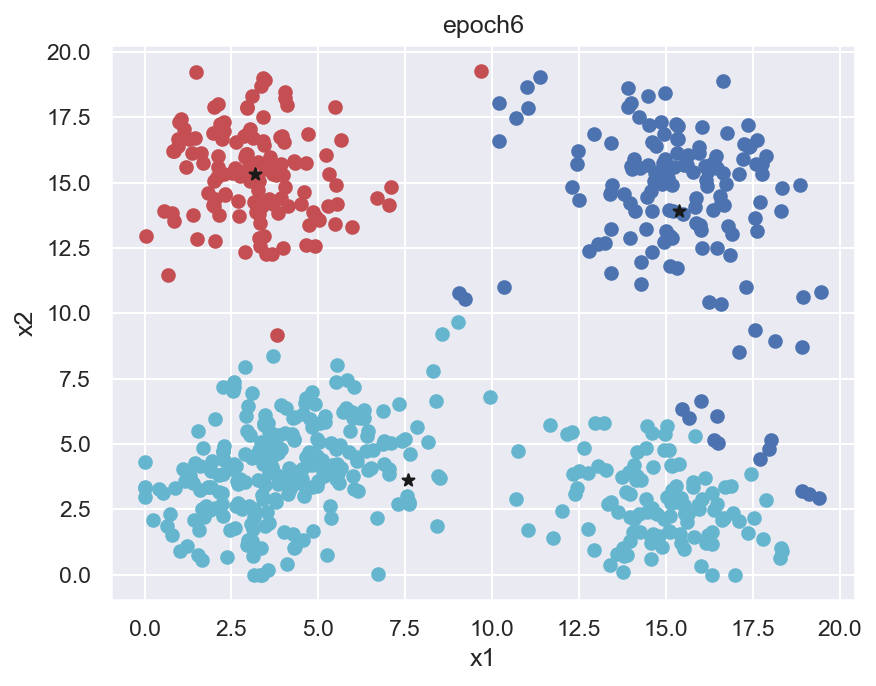

收敛于第6次迭代


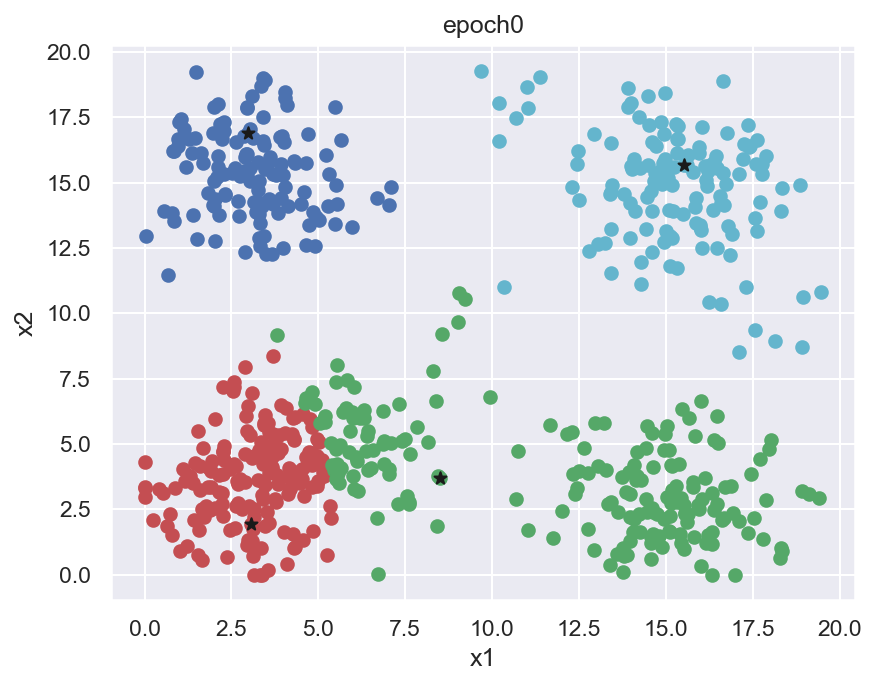

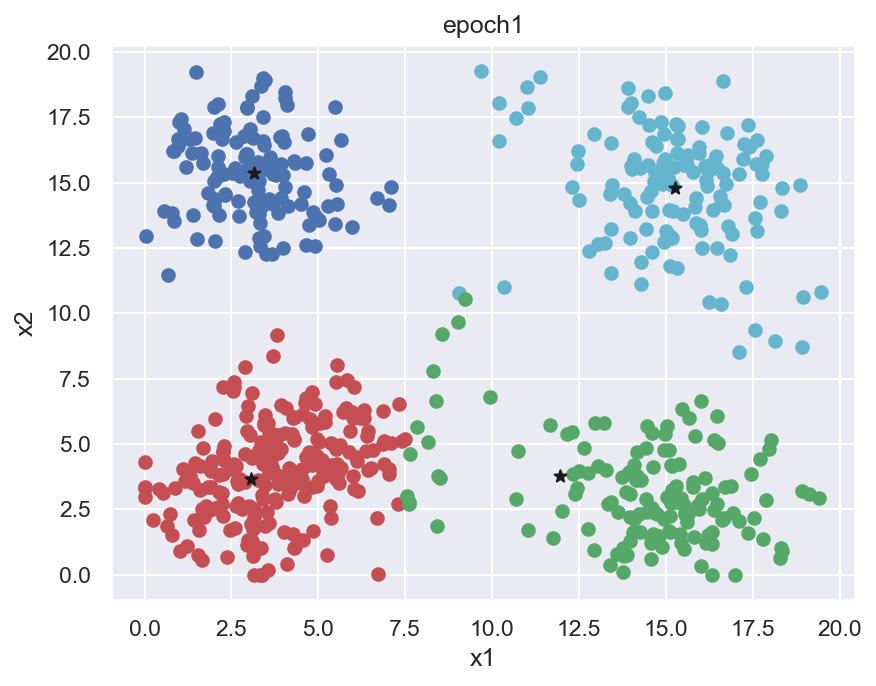

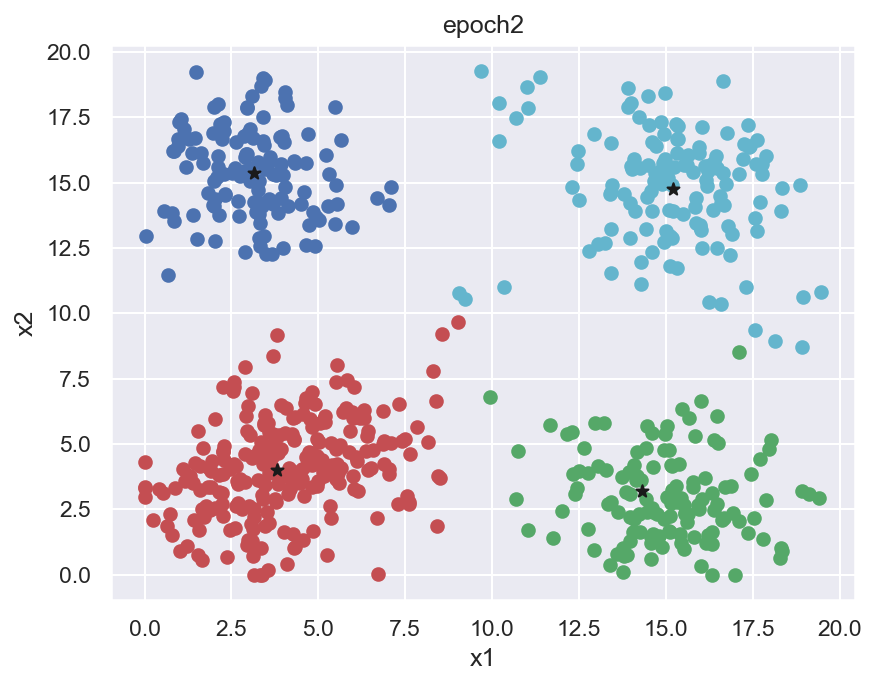

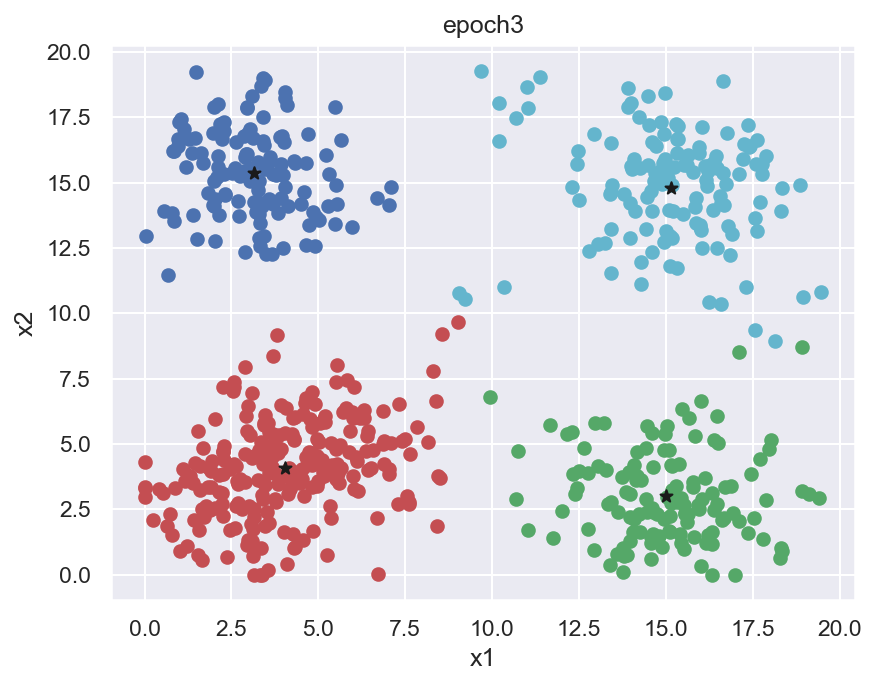

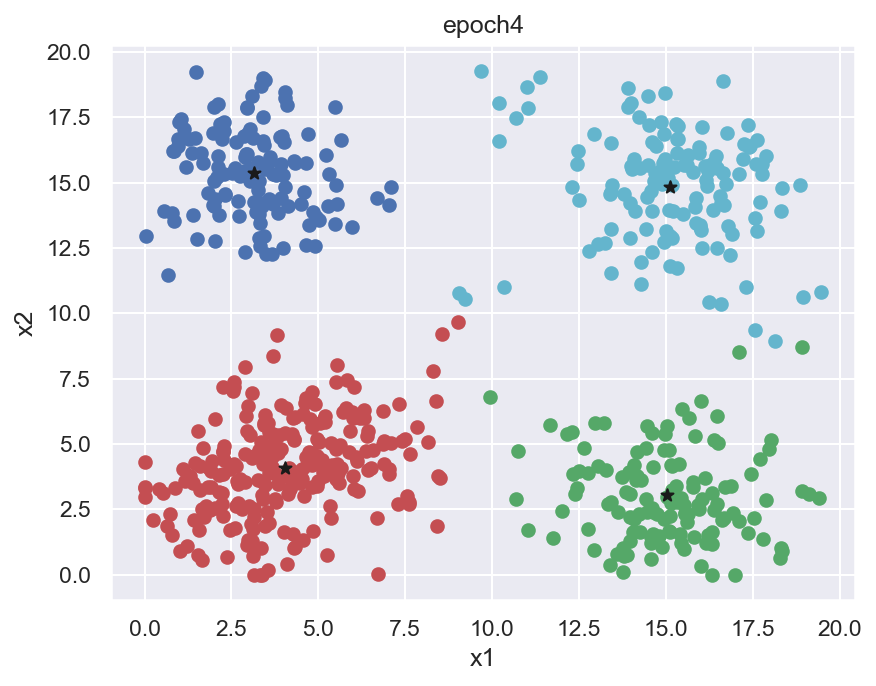

收敛于第4次迭代


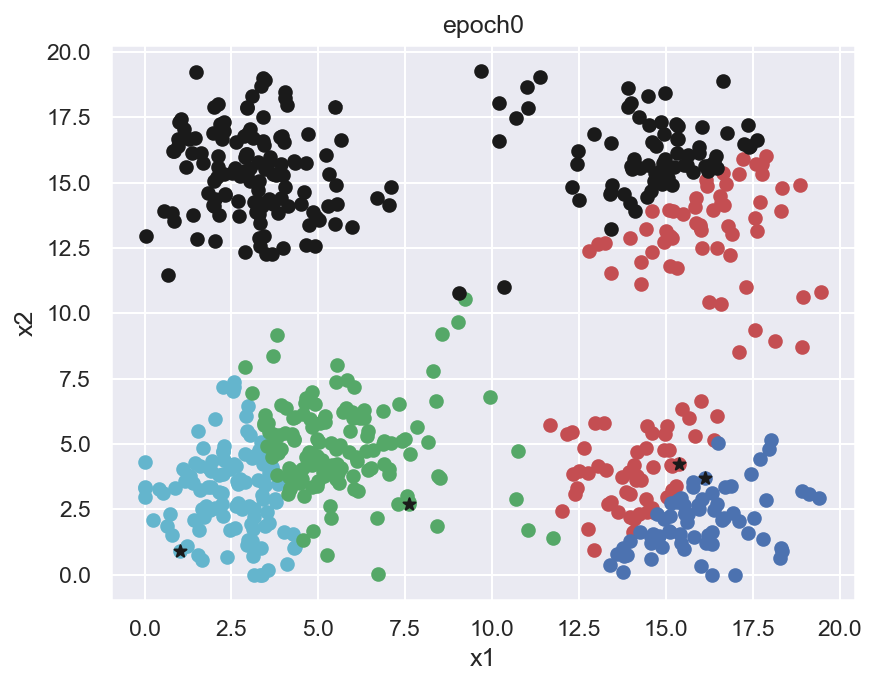

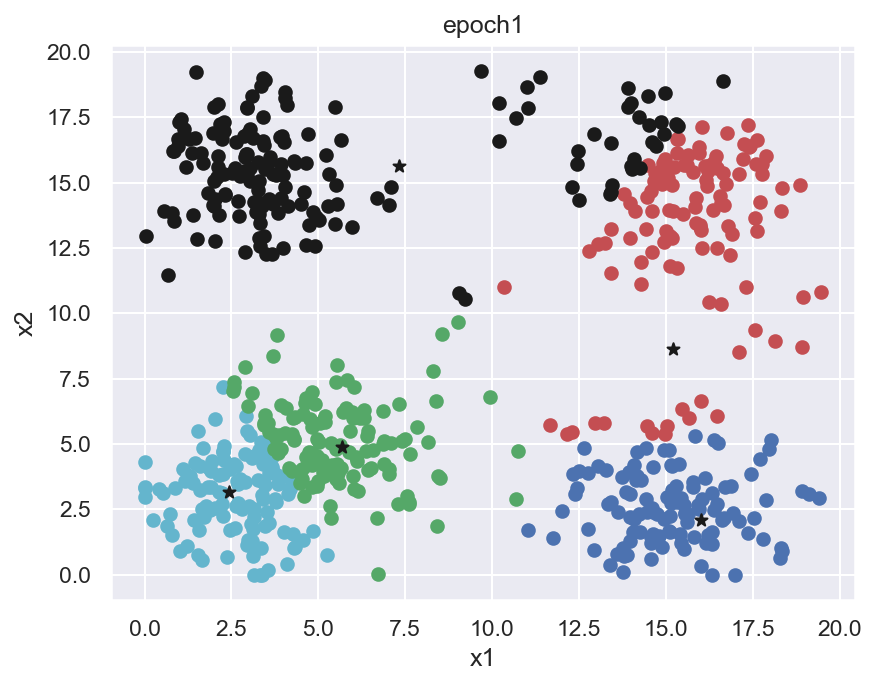

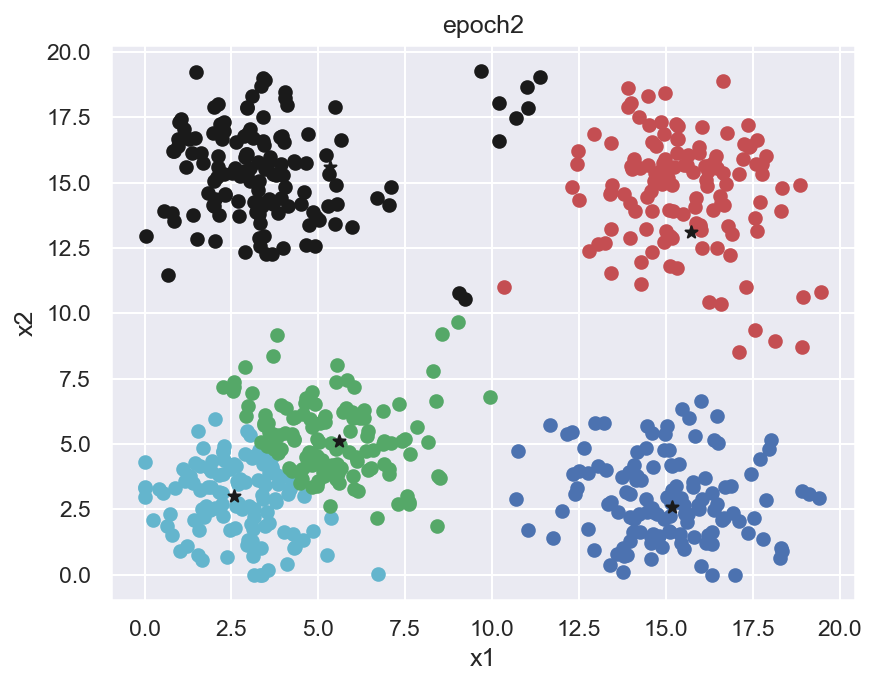

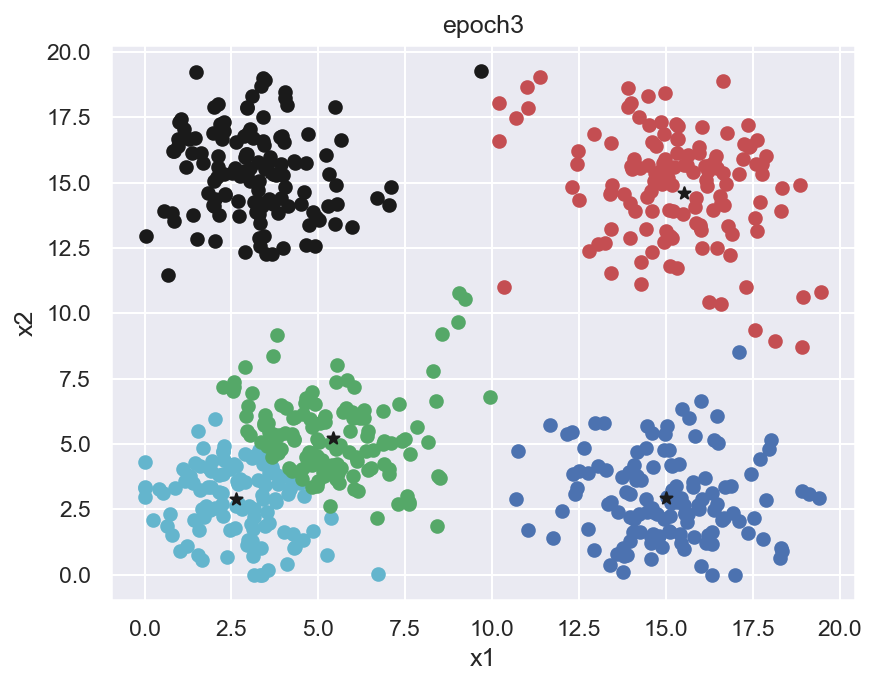

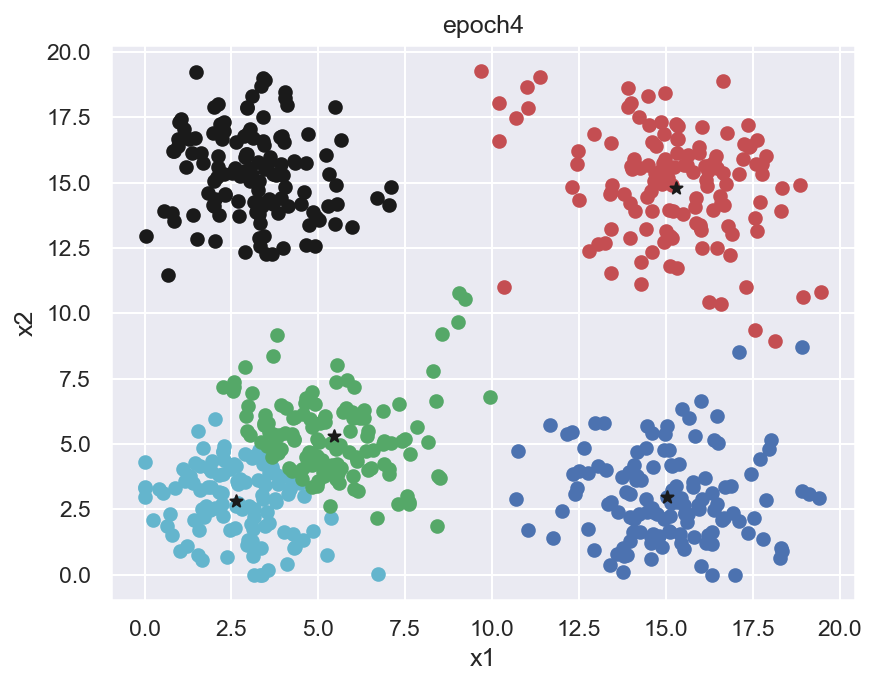

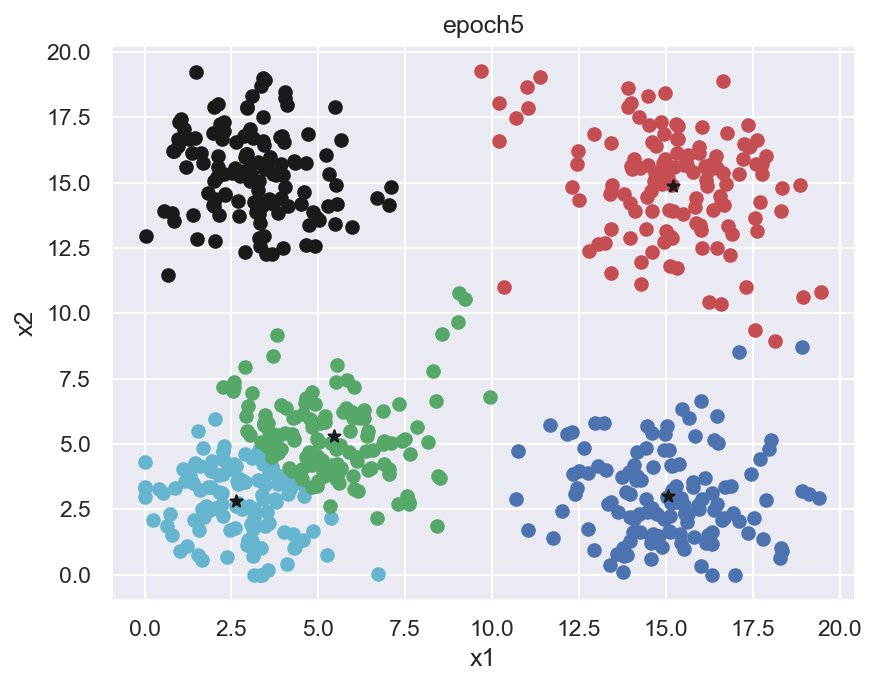

收敛于第5次迭代


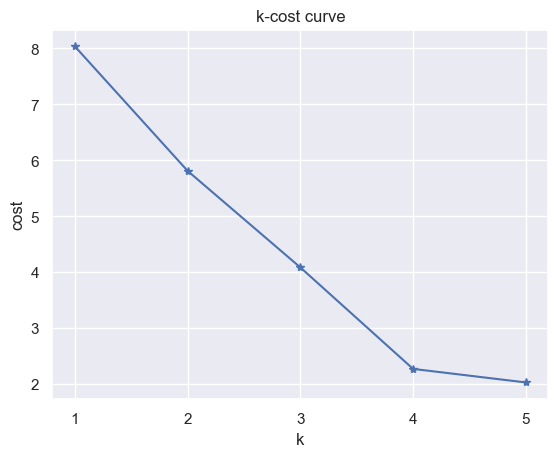

In [30]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,True)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()